In [20]:
# Install Loftr
# pip install kornia opencv-python
# Using korinia to load loftr

import torch
import kornia.feature as KF
import os
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

HPATCHES_PATH = "../hpatches-sequences-release"

# Load LoFTR by kornia

In [13]:
#Load Loftr
matcher = KF.LoFTR(pretrained='outdoor') #Since Hpatches is outdoor dataset, we use the outdoor pretrained model.
matcher = matcher.eval().cuda()

## Load HPatches Dataset

Each sequence has a reference image (`1.ppm`) paired with 5 test images (`2–6.ppm`) and their ground-truth homographies (`H_1_2 … H_1_6`).  
Sequences prefixed `i_` are illumination changes; `v_` are viewpoint changes.

In [15]:
def load_hpatches_pairs(hpatches_path):
    """Return list of dicts, one per image pair (580 total for the full dataset)."""
    pairs = []
    for seq_path in sorted(Path(hpatches_path).iterdir()):
        if not seq_path.is_dir():
            continue
        seq_name = seq_path.name
        img_ref = cv2.imread(str(seq_path / "1.ppm"))
        for i in range(2, 7):
            img_test = cv2.imread(str(seq_path / f"{i}.ppm"))
            H_gt = np.loadtxt(str(seq_path / f"H_1_{i}"))
            pairs.append({
                "seq":  seq_name,
                "idx":  i,
                "img0": img_ref,
                "img1": img_test,
                "H_gt": H_gt,
                "type": "illumination" if seq_name.startswith("i_") else "viewpoint",
            })
    return pairs

pairs = load_hpatches_pairs(HPATCHES_PATH)
n_illum = sum(1 for p in pairs if p["type"] == "illumination")
n_view  = sum(1 for p in pairs if p["type"] == "viewpoint")
print(f"Total pairs: {len(pairs)}  |  illumination: {n_illum}  |  viewpoint: {n_view}")

Total pairs: 580  |  illumination: 285  |  viewpoint: 295


## LoFTR Inference Helpers

Images are resized so the longest edge ≤ 840 px and both dimensions are multiples of 8 (required by LoFTR's coarse grid).  
Matched keypoints are then scaled back to the **original** image resolution before homography estimation.

In [18]:
def preprocess_image(img, short_edge=480):
    """Resize BGR image for LoFTR; shortest side = 480, dims multiples of 8."""
    h, w = img.shape[:2]
    scale = short_edge / min(h, w)
    new_w = int(w * scale) // 8 * 8
    new_h = int(h * scale) // 8 * 8
    img_resized = cv2.resize(img, (new_w, new_h))
    sx = new_w / w
    sy = new_h / h
    return img_resized, sx, sy


def to_tensor(img):
    """BGR image → grayscale CUDA tensor [1, 1, H, W] in [0, 1]."""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    t = torch.from_numpy(gray).float() / 255.0
    return t.unsqueeze(0).unsqueeze(0).cuda()


def run_loftr_pair(matcher, img0, img1):
    img0_r, sx0, sy0 = preprocess_image(img0)
    img1_r, sx1, sy1 = preprocess_image(img1)

    with torch.no_grad():
        corr = matcher({"image0": to_tensor(img0_r), "image1": to_tensor(img1_r)})

    mkpts0 = corr["keypoints0"].cpu().numpy()
    mkpts1 = corr["keypoints1"].cpu().numpy()
    return mkpts0, mkpts1, img0_r.shape, img1_r.shape, (sx0, sy0), (sx1, sy1)

## Homography Estimation & AUC Evaluation

**Corner transfer error**: the ground-truth homography H and the estimated H' are both applied to the 4 corners of image 0; the mean L2 distance between the two sets of projected corners is the error for that pair.

**AUC@N**: area under the recall-vs-threshold curve from 0 → N pixels, normalised to [0, 1].  
A pair that fails RANSAC (< 4 matches) contributes error = ∞ (always incorrect).

In [19]:
def estimate_homography(mkpts0, mkpts1, ransac_thr=3.0):
    if len(mkpts0) < 4:
        return None
    H, _ = cv2.findHomography(
        mkpts0, mkpts1, cv2.RANSAC, 
        ransac_thr, 
        confidence=0.99999,
        maxIters=10000
    )
    return H


def corner_transfer_error(H_pred, H_gt, img_shape):
    """
    Mean L2 distance (pixels) between corners projected by H_pred vs H_gt.
    Returns None if H_pred is None.
    """
    if H_pred is None:
        return None
    h, w = img_shape[:2]
    corners = np.array([[0, 0], [w - 1, 0], [w - 1, h - 1], [0, h - 1]],
                       dtype=np.float32).reshape(1, -1, 2)
    pred_pts = cv2.perspectiveTransform(corners, H_pred).reshape(-1, 2)
    gt_pts   = cv2.perspectiveTransform(corners, H_gt).reshape(-1, 2)
    return float(np.mean(np.linalg.norm(pred_pts - gt_pts, axis=1)))


def auc_at(errors, max_thr):
    """
    AUC of the correctness curve over [0, max_thr].
    errors: list of float | None  (None → failure, treated as infinity)
    Returns scalar in [0, 1].
    """
    xs = np.linspace(0, max_thr, 1000)
    ys = np.array([
        np.mean([(e is not None) and (e <= t) for e in errors])
        for t in xs
    ])
    return float(np.trapzoid(ys, xs) / max_thr), xs, ys

def scale_homography(H_gt, sx0, sy0, sx1, sy1):
    """Turn original resolution H_gt to the resized coordinate system"""
    S0 = np.array([[sx0, 0, 0], [0, sy0, 0], [0, 0, 1]])      # 原图→resize (图0)
    S1_inv = np.array([[1/sx1, 0, 0], [0, 1/sy1, 0], [0, 0, 1]]) # resize→原图 (图1)
    return S0 @ H_gt @ S1_inv

## Run LoFTR on All HPatches Pairs

In [ ]:
results = []

for pair in tqdm(pairs, desc="LoFTR on HPatches"):
    img0, img1, H_gt = pair["img0"], pair["img1"], pair["H_gt"]

    mkpts0, mkpts1, shape0_r, shape1_r, scale0, scale1 = run_loftr_pair(matcher, img0, img1)

    # H_gt 缩放到 resize 后的坐标系
    H_gt_scaled = scale_homography(H_gt, scale0[0], scale0[1], scale1[0], scale1[1])

    H_pred = estimate_homography(mkpts0, mkpts1)
    err = corner_transfer_error(H_pred, H_gt_scaled, shape0_r)  # 用 resize 后的 shape

    results.append({
        "seq":       pair["seq"],
        "idx":       pair["idx"],
        "type":      pair["type"],
        "n_matches": len(mkpts0),
        "error":     err,
    })

n_ok = sum(1 for r in results if r["error"] is not None)
print(f"Homography estimated for {n_ok}/{len(results)} pairs.")

LoFTR on HPatches: 100%|██████████| 580/580 [01:08<00:00,  8.42it/s]

Done. Homography estimated for 580/580 pairs.


## Homography AUC Results

Metric         |      All |  Illumination |  Viewpoint
------------------------------------------------------
  AUC @  3px   |   54.17% |        72.34% |     36.62%
  AUC @  5px   |   65.44% |        82.33% |     49.12%


C:\Users\EasyMoneySniper\AppData\Local\Temp\ipykernel_29892\2492564992.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(ys, xs) / max_thr), xs, ys


  AUC @ 10px   |   77.20% |        90.45% |     64.40%


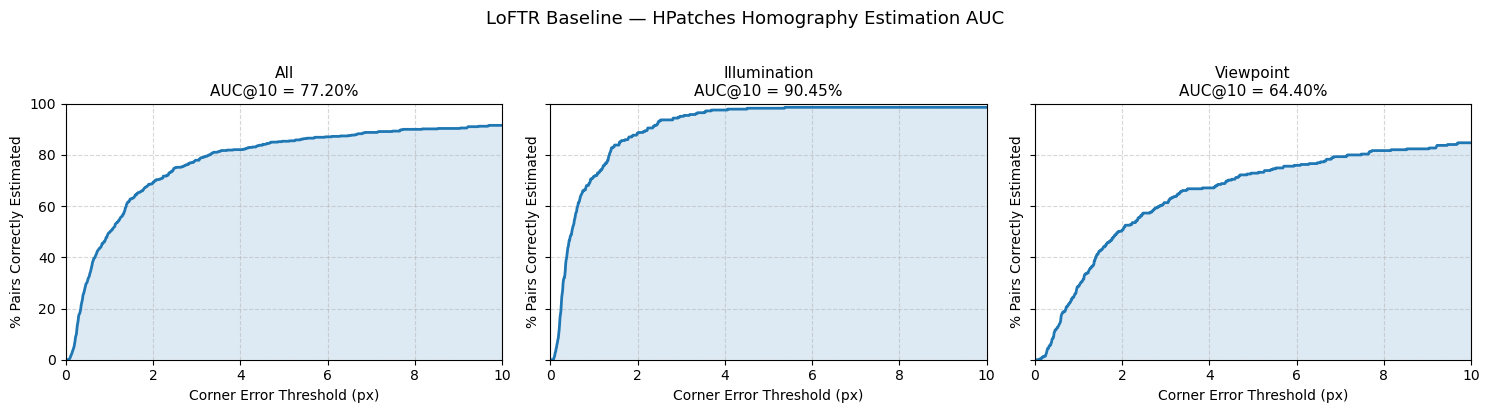

In [8]:
errors_all   = [r["error"] for r in results]
errors_illum = [r["error"] for r in results if r["type"] == "illumination"]
errors_view  = [r["error"] for r in results if r["type"] == "viewpoint"]

THRESHOLDS = [3, 5, 10]

# ── Print table ──────────────────────────────────────────────────────────────
header = f"{'Metric':<14} | {'All':>8} | {'Illumination':>13} | {'Viewpoint':>10}"
print(header)
print("-" * len(header))
for t in THRESHOLDS:
    a_all,  _, _ = auc_at(errors_all,   max_thr=t)
    a_i,    _, _ = auc_at(errors_illum, max_thr=t)
    a_v,    _, _ = auc_at(errors_view,  max_thr=t)
    print(f"  AUC @ {t:>2}px   | {a_all*100:7.2f}% | {a_i*100:12.2f}% | {a_v*100:9.2f}%")

# ── Plot AUC curves ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
splits = [
    (errors_all,   "All"),
    (errors_illum, "Illumination"),
    (errors_view,  "Viewpoint"),
]
for ax, (errs, label) in zip(axes, splits):
    auc_val, xs, ys = auc_at(errs, max_thr=10)
    ax.plot(xs, ys * 100, linewidth=2)
    ax.fill_between(xs, ys * 100, alpha=0.15)
    ax.set_title(f"{label}\nAUC@10 = {auc_val * 100:.2f}%", fontsize=11)
    ax.set_xlabel("Corner Error Threshold (px)")
    ax.set_ylabel("% Pairs Correctly Estimated")
    ax.set_xlim([0, 10])
    ax.set_ylim([0, 100])
    ax.grid(True, linestyle="--", alpha=0.5)

fig.suptitle("LoFTR Baseline — HPatches Homography Estimation AUC", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("loftr_hpatches_auc.png", dpi=150, bbox_inches="tight")
plt.show()